# Day one Random Number generator

In [171]:
# Write a program implementing a linear congruential generator
#(LCG). Be sure that the program works correctly using only
#integer representation

# TASK 1A AND 1B
import numpy as np

def linear_congruential(x0, a, c, M, n_loop):
    """ 
    x0 is the initial number, 
    a is the multiplyer
    c is the constant added
    M is the modulus
    """

    x_list = [x0]
    current_x = x0

    for i in range (n_loop):
        current_x = (a * current_x + c) % M
        x_list.append(current_x)
    
    return np.array(x_list)/M
# x0 = 42
# a= 16807
# c = 0

# M = 2**31-1
# k = 10_000
x0 = 42
a= 100
c = 5

M = 2**16-1
k = 10_000

x_list = linear_congruential(x0, a, c, M, k)
x_list

array([6.40878920e-04, 6.41641871e-02, 4.16495003e-01, ...,
       8.89600977e-02, 8.96086061e-01, 6.08682383e-01], shape=(10001,))

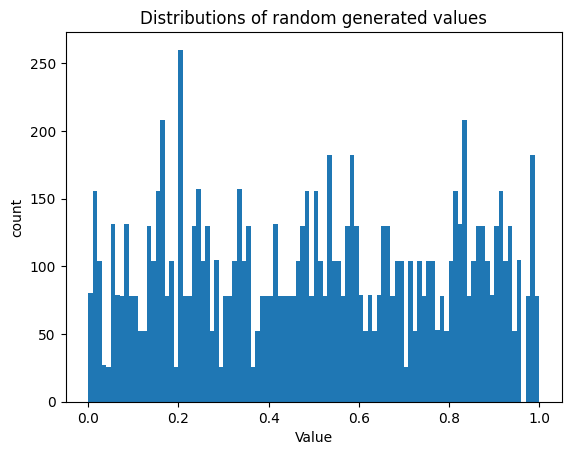

In [172]:
import matplotlib.pyplot as plt

plt.hist(x_list, bins=100)
plt.xlabel('Value')
plt.ylabel('count')
plt.title('Distributions of random generated values')
plt.show()

Text(0.5, 1.0, 'Scatter of concecutive points agains each other')

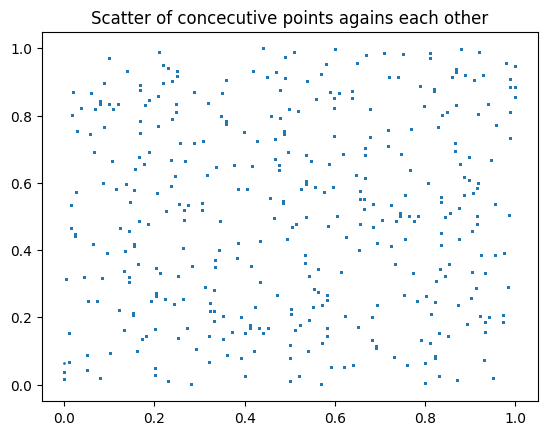

In [173]:
# scatter plot
plt.scatter(x_list[:-1], x_list[1:], s=1)
plt.title('Scatter of concecutive points agains each other')


In [174]:
# statistical tests - χ^2
classes = 10
expected_n = len(x_list)/classes
observed_n, bin_edges = np.histogram(x_list, bins=classes)

T = np.sum((observed_n-expected_n)**2/expected_n)

In [175]:
# Degress of freedom df = n_classes -1-m, where m i s the number of estimated paramters, here 0

# df = 10-1 = 9
# Critical value er 16.919
df = classes-1
print('Degrees of fredom: ',df)

critical_value = 16.919
# We have looked up the critical value for this degree of freedom for the p value p = 0.95
# Since T=5.49 < df we cannot reject the nul-hypothesis, (that the distribution is uniform)


Degrees of fredom:  9


In [176]:
# Kolmogorov-Smirnov 
# compare empirical distribution function Fn(x) with hypothesixed distribution

expected_list = [i*expected_n for i in range(classes)]
observed_n = np.array(observed_n)
observed_list = [int(np.sum(observed_n[:i])) for i in range(len(observed_n))]
observed_list, expected_list


([0, 890, 1878, 2998, 3883, 4872, 6120, 7007, 7762, 8986],
 [0.0, 1000.1, 2000.2, 3000.3, 4000.4, 5000.5, 6000.6, 7000.7, 8000.8, 9000.9])

Passing test with critical value? - True


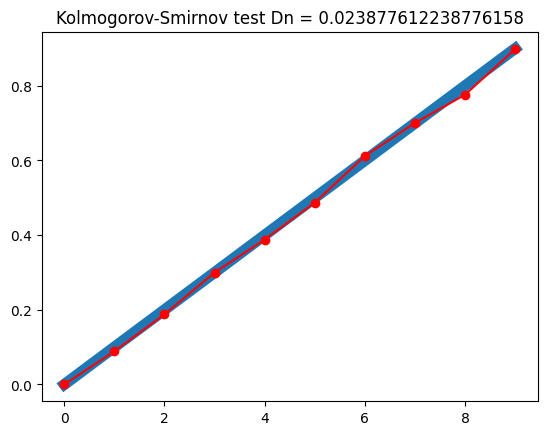

In [177]:
n = len(x_list)
observed_list =np.array(observed_list)/n
expected_list = np.array(expected_list)/n
plt.plot(expected_list, linewidth=8)

plt.plot(list(range(0, classes)), observed_list, c='r', marker='o')

Dn = np.max(np.abs(observed_list-expected_list))
plt.title(f"Kolmogorov-Smirnov test Dn = {Dn}")
print(f"Passing test with critical value? - {critical_value>Dn}")

In [178]:
# all paramteters known 
n = len(x_list)
adjusted_test_statistic = (np.sqrt(n)+0.12+0.11/np.sqrt(n))*Dn

print(f"Adjusted test statistical = {adjusted_test_statistic} ")
print(f"Passing test with critical value? - {critical_value>adjusted_test_statistic}")

Adjusted test statistical = 2.390772186483203 
Passing test with critical value? - True


### Run tests

In [179]:
# Run test 1
median_ = np.median(x_list)
# n1: number of samples above median
n1 = np.sum(x_list>median_)
# n2: number of samples below median
n2 = np.sum(x_list<median_)



In [180]:

Ra = 0
Rb = 0
runs_above = x_list>median_
runs_below = x_list<median_

if runs_above[0]==True:
    Ra+=1
if runs_below[0]==True:
    Rb+=1
for i in range(1, len(x_list)):

    # mark every start
    if runs_above[i]==True and runs_above[i-1]==False:
        Ra +=1
    if runs_below[i]==True and runs_below[i-1]==False:
        Rb +=1

T = Ra + Rb
print(f"Ra = {Ra} and Rb = {Rb} \nT={T}")

# gausian (normal dist)
mean_normal = 2*n1*n2/(n1+n2)+1
variance_normal = 2* n1*n2*(2*n1*n2-n1-n2)/((n1+n2)**2*(n1+n2-1))

z_score = (T-mean_normal)/np.sqrt(variance_normal)
print(f"\nz-score = {z_score}")
print(f"Passing test with critical value? - {critical_value>z_score}")


Ra = 2500 and Rb = 2500 
T=5000

z-score = 0.23083182941363808
Passing test with critical value? - True


In [181]:
# Run test II ()Up/down from Knuth
from collections import Counter
r =1

index_shifts = [0]
for i in range(1, len(x_list)):
    # mark every start
    if x_list[i-1] > x_list[i] :
        r +=1
        index_shifts.append(i)
if i not in index_shifts:
    print(i)
    index_shifts.append(i)
else :
    print(index_shifts[-1])

print(f"Runs r = {r} \n")

Run_lengths = np.diff(index_shifts)

R = np.zeros(6).astype(int)

R[0] = int(np.sum(Run_lengths==1))
R[1] = int(np.sum(Run_lengths==2))
R[2] = int(np.sum(Run_lengths==3))
R[3] = int(np.sum(Run_lengths==4))
R[4] = int(np.sum(Run_lengths==5))
R[5] = int(np.sum(Run_lengths>5))
R

10000
Runs r = 5130 



array([1823, 2159,  808,  260,   79,    0])

In [182]:
A = np.array([
    [4529.4,  9044.9,  13568.0,  18091.0,  22615.0,  27892.0],
    [9044.9, 18097.0,  27139.0,  36187.0,  45234.0,  55789.0],
    [13568.0, 27139.0,  40721.0,  54281.0,  67852.0,  83685.0],
    [18091.0, 36187.0,  54281.0,  72414.0,  90470.0, 111580.0],
    [22615.0, 45234.0,  67852.0,  90470.0, 113262.0, 139476.0],
    [27892.0, 55789.0,  83685.0, 111580.0, 139476.0, 172860.0]
])

B = np.array([
    1/6,
    5/24,
    11/120,
    19/720,
    29/5040,
    1/840
])
print(f"R = {R}")

Z = (1 / (n - 6)) * (R - n * B).T @ A @ (R - n * B)
print(f"Z = {Z}")
print(f"Passing test with critical value? - {critical_value>Z}")

R = [1823 2159  808  260   79    0]
Z = 54.46085192202013
Passing test with critical value? - False


### Correlation test

In [186]:
# h is the lag we want to skip with 
h = 2

indexes_to_search = np.arange(0,len(x_list),h)


UiUih = [x_list[i]*x_list[i+h] for i in range(n-h)]
UiUih = np.array(UiUih)
ch = 1/(n-h)* np.sum(UiUih)
print(f"ch= {ch}")
expected_mean = 0.25
variance = 7 / (144 * k)     # Notice the parentheses around (144 * k)
std_dev = np.sqrt(variance)

# 3. Calculate the actual Z-test statistic using your calculated 'c'
Z = (ch - expected_mean) / std_dev
print(f"Standardized correlation test statistic: {Z:.2f}")
print(f"Passing test with critical value? - {critical_value>Z}")

ch= 0.2558454717453179
Standardized correlation test statistic: 2.65
Passing test with critical value? - False


## Task 2 system availale generator 

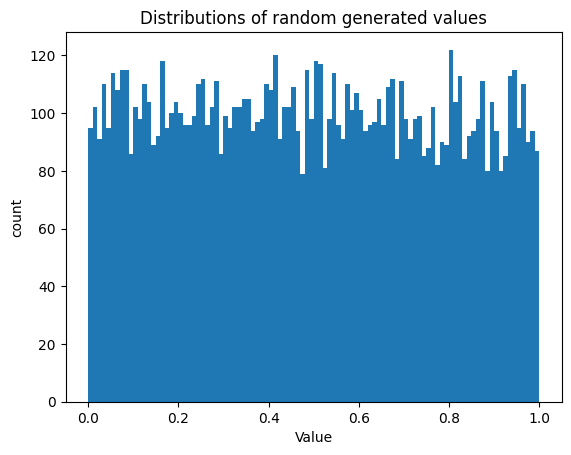


PASSED : (statistical_test_X2) T value T = 10.111888811118886 is less than critical value 16.919

PASSED : (Kolmogorov_Smirnov_test) Dn value Dn = 0.011328867113288732 is less than critical value 1.358

PASSED : (Run-test1) z_score value z_score = 1.2200610106769065 is less than critical value 1.96

PASSED :(Run-test2) Z value Z = 1.2701902419777191 is less than critical value 12.592

PASSED : (Correlation test) Z value Z = -2.750349528080292 is less than critical value 1.96


np.float64(-2.750349528080292)

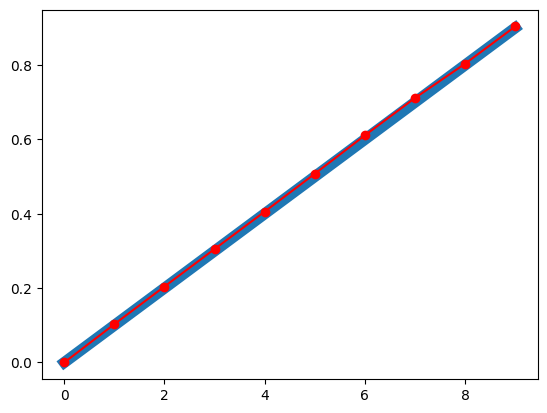

In [196]:
np.random.seed(42)
from importlib import reload

import RNG_mat
reload(RNG_mat)
uniform_numpy = np.random.uniform(0,1,10_001)
RNG_mat.show_hist(uniform_numpy, bins=100 )

classes = 10
critical_value_Xhi = 16.919
RNG_mat.perform_statistical_test_X2(uniform_numpy,critical_value=critical_value_Xhi, classes=10 )
critical_value_smirnov = 1.358
RNG_mat.perform_Kolmogorov_Smirnov_test(uniform_numpy,critical_value=critical_value_smirnov, classes=10 )

critical_value_runtest1 = 1.96
RNG_mat.perform_run_test1(uniform_numpy,critical_value=critical_value_runtest1)

critical_value_test2 = 12.592
RNG_mat.perform_run_test2(uniform_numpy,critical_value=critical_value_test2)
critical_value_correlation = 1.96
RNG_mat.perform_correlation_test(uniform_numpy,critical_value=critical_value_correlation,h=4)
